#### Import necessary libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

#### User defined functions. Must  runt his cell before they can be used.

In [33]:
def generate_dummy_data(mode="beats"):
    np.random.seed(0)
    t = np.linspace(0, 20, 1000)

    if mode == "in_phase":
        A1, A2 = 1.0, 1.0
        f1, f2 = 0.5, 0.5
        phi1, phi2 = 0.0, 0.0

    elif mode == "out_of_phase":
        A1, A2 = 1.0, 1.0
        f1, f2 = 0.5, 0.5
        phi1, phi2 = 0.0, np.pi

    elif mode == "beats":
        A1, A2 = 1.0, 0.8
        f1, f2 = 0.5, 0.55
        phi1, phi2 = 0.0, 0.5

    offset = 0.1

    y = (A1 * np.cos(2 * np.pi * f1 * t + phi1) +
         A2 * np.cos(2 * np.pi * f2 * t + phi2) +
         offset)

    noise = 0.2 * np.random.normal(size=len(t))
    return t, y + noise

In [34]:
USE_DUMMY = True
MODE = "beats"

if USE_DUMMY:
    t, y = generate_dummy_data(MODE)
else:
    data = t, y = generate_dummy_data("your_csv_file.csv")  # Replace with your actual CSV file path        
    t = data["time"].values
    y = data["signal"].values

In [35]:
# --- Define the cosine model ---
def cosine_model(t, A, f, phi, offset):
    return A * np.cos(2 * np.pi * f * t + phi) + offset

# Define the beat model (two coupled oscillators) ---
def beat_func(t, A1, A2, f1, f2, phi1, phi2, offset):
    return A1 * np.cos(2 * np.pi * f1 * t + phi1) + \
           A2 * np.cos(2 * np.pi * f2 * t + phi2) + offset

# Plotting the x vs t graph
def plotter(t,y,start,end,title):
    mask = (t >= start) & (t <= end)
    t_zoom = t[mask]
    y_zoom = y[mask]

    plt.figure(figsize=(10, 5))
    plt.plot(t_zoom, y_zoom, label="Data", lw=1)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.legend()
    plt.show()
    return t_zoom,y_zoom
    
    
# fit cosine date
def fit_cosine_data(t,y):
# --- Step 1: Provide initial parameter guesses ---
    A0 = (np.max(y) - np.min(y)) / 2
    offset0 = np.mean(y)
    
    # Rough frequency estimate using FFT
    yf = np.fft.rfft(y - offset0)
    xf = np.fft.rfftfreq(len(t), t[1] - t[0])
    omega0 = xf[np.argmax(np.abs(yf[1:])) + 1]  # avoid DC component
    phi0 = 0.0

    initial_guess = [A0, omega0, phi0, offset0]

    # Fit the data ---
    popt, pcov = curve_fit(cosine_model, t, y, p0=initial_guess)

    # Compute fitted values ---
    fit_y = cosine_model(t, *popt)
    
    return popt, pcov, fit_y

# Perform fft
def analyze_fft(t, y, title,fmin=0.25, fmax=0.9, peak_threshold=0.2, plot=True):
    """
    Performs FFT analysis on a time-domain signal and plots the amplitude spectrum.

    Parameters
    ----------
    t : array-like
        Time array.
    y : array-like
        Signal array corresponding to t.
    fmin : float, optional
        Minimum frequency limit for the plot (default = 0.25 Hz).
    fmax : float, optional
        Maximum frequency limit for the plot (default = 0.9 Hz).
    peak_threshold : float, optional
        Fraction of the maximum amplitude used for peak detection (default = 0.2).
    plot : bool, optional
        If True, displays the FFT amplitude spectrum.

    Returns
    -------
    freq : ndarray
        Frequency axis (positive frequencies only).
    amplitude : ndarray
        Normalized FFT amplitude spectrum.
    dominant_freqs : ndarray
        Detected dominant frequencies in Hz.
    """
    # --- Step 1: Compute sampling parameters ---
    dt = t[1] - t[0]           # time step
    fs = 1 / dt                # sampling frequency
    N = len(y)                 # number of data points

    # --- Step 2: Perform FFT ---
    Y = np.fft.fft(y - np.mean(y))   # remove DC offset
    freq = np.fft.fftfreq(N, d=dt)

    # Only positive half
    mask = freq > 0
    freq = freq[mask]
    amplitude = np.abs(Y[mask]) * 2 / N

    # --- Step 3: Find dominant peaks ---
    peaks, _ = find_peaks(amplitude, height=np.max(amplitude) * peak_threshold)
    dominant_freqs = freq[peaks]

    # --- Step 4: Plot if requested ---
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(freq, amplitude, 'r-', linewidth=1.5)
        plt.xlim([fmin, fmax])
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Amplitude (normalized)")
        plt.title("FFT Spectrum of   " + title +"Oscillator")
        plt.grid(True)
        plt.show()

    # --- Step 5: Print dominant frequencies ---
    print("Dominant frequencies (Hz):", np.round(dominant_freqs, 4))

    return freq, amplitude, dominant_freqs

# plot the data and the superimpose the fitted data
def fit_plotter(t,y,yfit):
    plt.figure(figsize=(10, 5))
    plt.plot(t, y, 'k.', label="Data (25–75 range)", markersize=4)
    plt.plot(t, yfit, 'r-', label="Fitted curve", linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title("Coupled Oscillator Fit (Zoomed: 25–75)")
    plt.legend()
    plt.show()


#### Load the in-phase,ou-phase and beats data. Also visulize and select the usable part of the data.

Minimum t: 0.0
Maximum t: 20.0


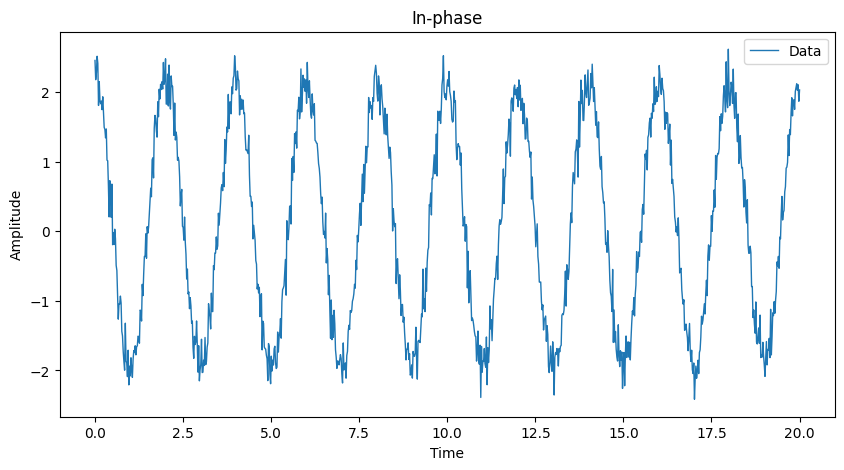

(array([ 0.        ,  0.02002002,  0.04004004,  0.06006006,  0.08008008,
         0.1001001 ,  0.12012012,  0.14014014,  0.16016016,  0.18018018,
         0.2002002 ,  0.22022022,  0.24024024,  0.26026026,  0.28028028,
         0.3003003 ,  0.32032032,  0.34034034,  0.36036036,  0.38038038,
         0.4004004 ,  0.42042042,  0.44044044,  0.46046046,  0.48048048,
         0.5005005 ,  0.52052052,  0.54054054,  0.56056056,  0.58058058,
         0.6006006 ,  0.62062062,  0.64064064,  0.66066066,  0.68068068,
         0.7007007 ,  0.72072072,  0.74074074,  0.76076076,  0.78078078,
         0.8008008 ,  0.82082082,  0.84084084,  0.86086086,  0.88088088,
         0.9009009 ,  0.92092092,  0.94094094,  0.96096096,  0.98098098,
         1.001001  ,  1.02102102,  1.04104104,  1.06106106,  1.08108108,
         1.1011011 ,  1.12112112,  1.14114114,  1.16116116,  1.18118118,
         1.2012012 ,  1.22122122,  1.24124124,  1.26126126,  1.28128128,
         1.3013013 ,  1.32132132,  1.34134134,  1.3

In [36]:
# Load the in_phase dummy data --- and plot it

t_inphase, y_inphase = generate_dummy_data("in_phase")

print("Minimum t:", np.min(t_inphase))
print("Maximum t:", np.max(t_inphase))

plotter(t_inphase,y_inphase,0,np.max(t_inphase),"In-phase")

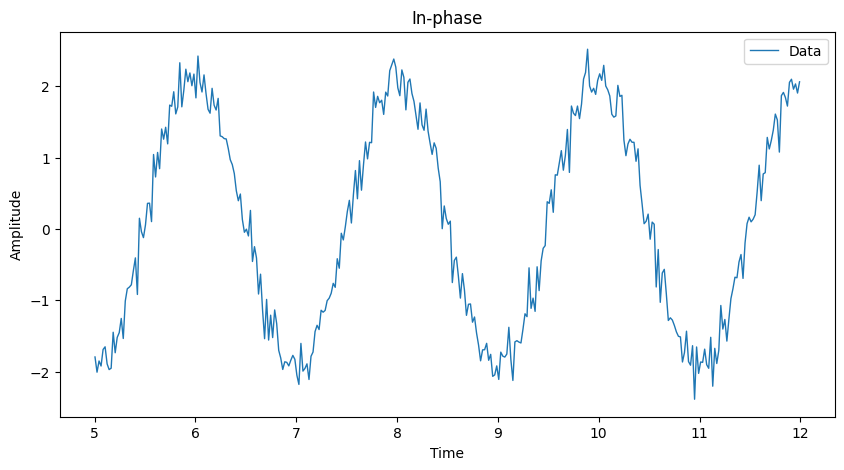

In [37]:
# Select usable data range - specify start and end times
ti,yi = plotter(t_inphase,y_inphase,5,12,"In-phase")

Minimum t: 0.0
Maximum t: 20.0


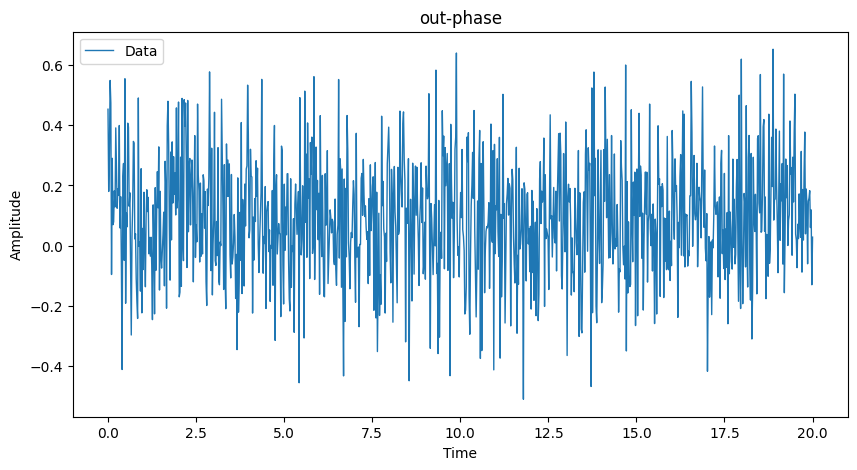

(array([ 0.        ,  0.02002002,  0.04004004,  0.06006006,  0.08008008,
         0.1001001 ,  0.12012012,  0.14014014,  0.16016016,  0.18018018,
         0.2002002 ,  0.22022022,  0.24024024,  0.26026026,  0.28028028,
         0.3003003 ,  0.32032032,  0.34034034,  0.36036036,  0.38038038,
         0.4004004 ,  0.42042042,  0.44044044,  0.46046046,  0.48048048,
         0.5005005 ,  0.52052052,  0.54054054,  0.56056056,  0.58058058,
         0.6006006 ,  0.62062062,  0.64064064,  0.66066066,  0.68068068,
         0.7007007 ,  0.72072072,  0.74074074,  0.76076076,  0.78078078,
         0.8008008 ,  0.82082082,  0.84084084,  0.86086086,  0.88088088,
         0.9009009 ,  0.92092092,  0.94094094,  0.96096096,  0.98098098,
         1.001001  ,  1.02102102,  1.04104104,  1.06106106,  1.08108108,
         1.1011011 ,  1.12112112,  1.14114114,  1.16116116,  1.18118118,
         1.2012012 ,  1.22122122,  1.24124124,  1.26126126,  1.28128128,
         1.3013013 ,  1.32132132,  1.34134134,  1.3

In [38]:
# Load the out_phase dummy data --- and plot it 
t_outphase, y_outphase = generate_dummy_data("out_of_phase")

print("Minimum t:", np.min(t_outphase))
print("Maximum t:", np.max(t_outphase))

plotter(t_outphase,y_outphase,0,np.max(t_outphase),"out-phase")

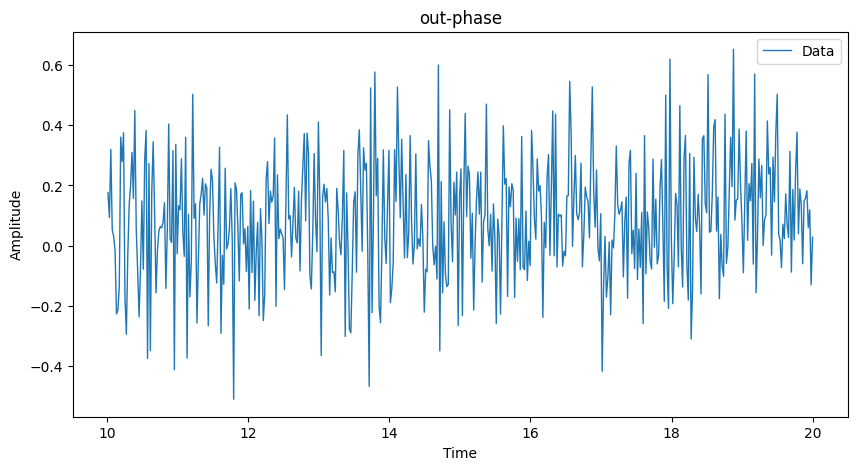

In [39]:
# Select usable data range - specify start and end times
to,yo = plotter(t_outphase,y_outphase,10,20,"out-phase")

Minimum t: 0.0
Maximum t: 20.0


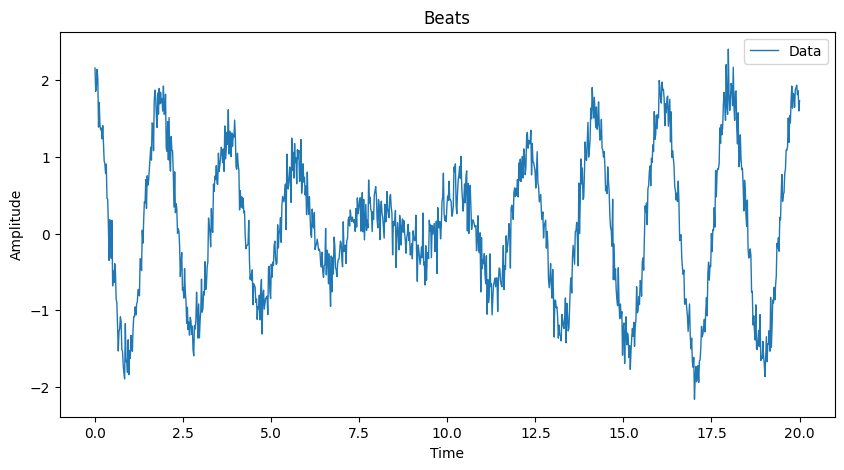

(array([ 0.        ,  0.02002002,  0.04004004,  0.06006006,  0.08008008,
         0.1001001 ,  0.12012012,  0.14014014,  0.16016016,  0.18018018,
         0.2002002 ,  0.22022022,  0.24024024,  0.26026026,  0.28028028,
         0.3003003 ,  0.32032032,  0.34034034,  0.36036036,  0.38038038,
         0.4004004 ,  0.42042042,  0.44044044,  0.46046046,  0.48048048,
         0.5005005 ,  0.52052052,  0.54054054,  0.56056056,  0.58058058,
         0.6006006 ,  0.62062062,  0.64064064,  0.66066066,  0.68068068,
         0.7007007 ,  0.72072072,  0.74074074,  0.76076076,  0.78078078,
         0.8008008 ,  0.82082082,  0.84084084,  0.86086086,  0.88088088,
         0.9009009 ,  0.92092092,  0.94094094,  0.96096096,  0.98098098,
         1.001001  ,  1.02102102,  1.04104104,  1.06106106,  1.08108108,
         1.1011011 ,  1.12112112,  1.14114114,  1.16116116,  1.18118118,
         1.2012012 ,  1.22122122,  1.24124124,  1.26126126,  1.28128128,
         1.3013013 ,  1.32132132,  1.34134134,  1.3

In [40]:
# Load the beats dummy data --- and plot it
t_beats, y_beats = generate_dummy_data("beats")

print("Minimum t:", np.min(t_beats))
print("Maximum t:", np.max(t_beats))

plotter(t_beats,y_beats,0,np.max(t_beats),"Beats")

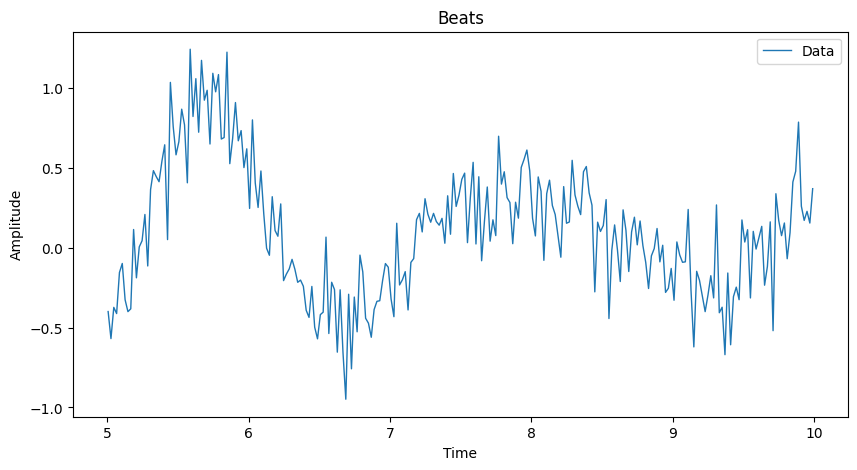

In [41]:
# Select usable data range - specify start and end times
tb,yb = plotter(t_beats,y_beats,5,10,"Beats")

#### Perform fft of all 3 data

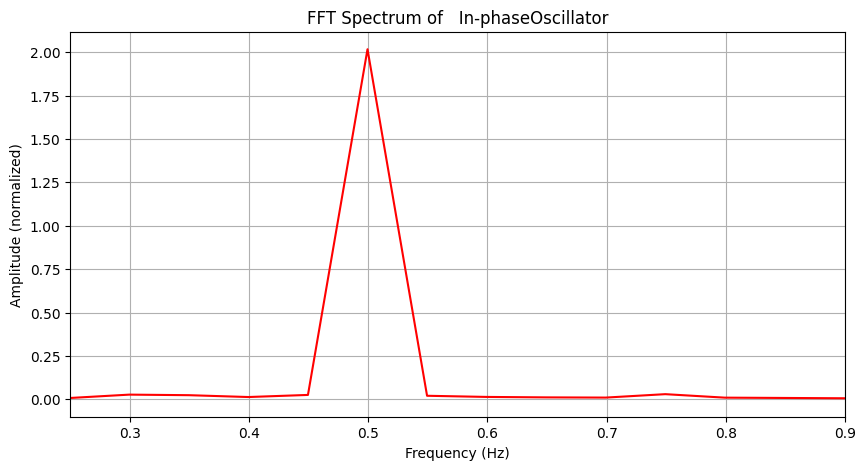

Dominant frequencies (Hz): [0.4995]


In [42]:
# fft of in-phase
freq, amp, peaks = analyze_fft(t_inphase, y_inphase,'In-phase')



#store the frequency value in a dataframe
df_freq = pd.DataFrame(columns=["FFT Frequency"])
df_freq.loc["in-phase", "FFT Frequency"] = peaks[0]




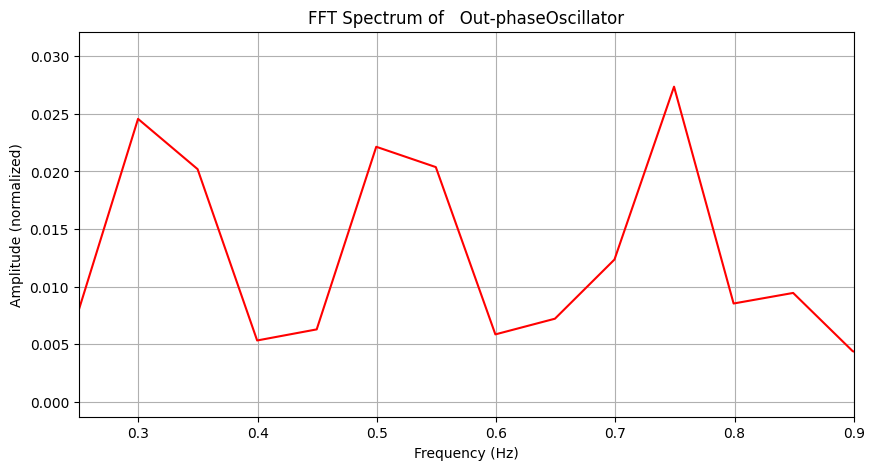

Dominant frequencies (Hz): [ 0.1998  0.2997  0.4995  0.7492  0.8492  1.049   1.2488  1.4486  1.5485
  1.7982  1.998   2.1478  2.2478  2.3477  2.4476  2.5974  2.7473  3.0969
  3.1968  3.2967  3.4466  3.5464  3.7462  3.8462  3.946   4.1458  4.2957
  4.5454  4.7453  4.8951  5.045   5.1948  5.2947  5.4945  5.6444  5.8442
  5.994   6.1439  6.3436  6.4436  6.5434  6.6933  6.8432  6.943   7.0929
  7.1928  7.3426  7.4426  7.5924  7.6923  7.8422  7.992   8.1418  8.3916
  8.4915  8.7413  8.8911  8.991   9.1408  9.2907  9.5404  9.7402  9.8402
  9.94   10.04   10.2398 10.3896 10.5394 10.6394 10.7392 10.8392 11.0889
 11.3386 11.4386 11.5385 11.6883 11.7882 11.938  12.1378 12.2877 12.5374
 12.7872 12.8871 13.0869 13.2368 13.3366 13.5364 13.6863 13.8362 13.936
 14.1858 14.4356 14.6354 14.7852 14.985  15.0849 15.2348 15.3846 15.5344
 15.6344 15.7342 15.934  16.1838 16.3336 16.4336 16.5335 16.6833 16.8831
 16.983  17.1328 17.2328 17.3326 17.4825 17.5824 17.7322 17.8322 17.982
 18.0819 18.2318 18.5314 1

,FFT Frequency
in-phase,0.4995
out-phase,0.1998


In [43]:
# fft of out-phase
freq, amp, peaks = analyze_fft(t_outphase, y_outphase, "Out-phase")
df_freq.loc["out-phase", "FFT Frequency"] = peaks[0]
df_freq

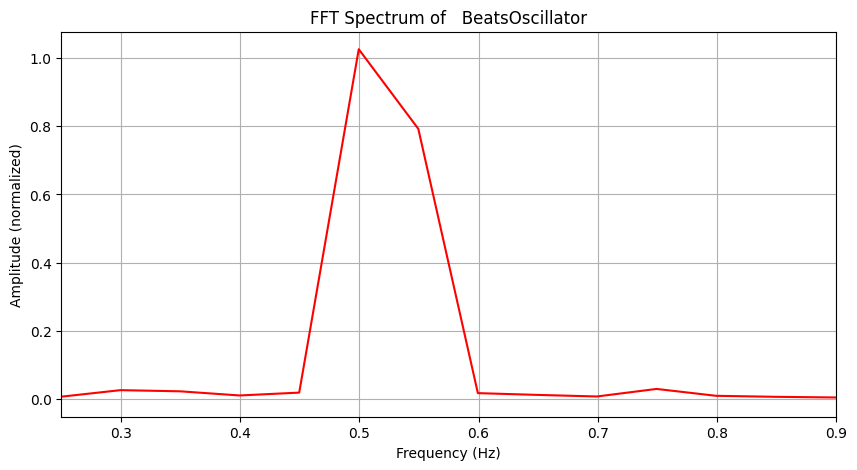

Dominant frequencies (Hz): [0.4995]


In [44]:
# fft of beats
freq3, amp, peaks = analyze_fft(t_beats, y_beats,'Beats')
#df_freq.loc["Beats-1", "FFT Frequency"] = peaks[0]
#df_freq.loc["Beats -2", "FFT Frequency"] = peaks[1]
#df_freq

[-2.01598975  0.49962873  3.16139209  0.07663194]


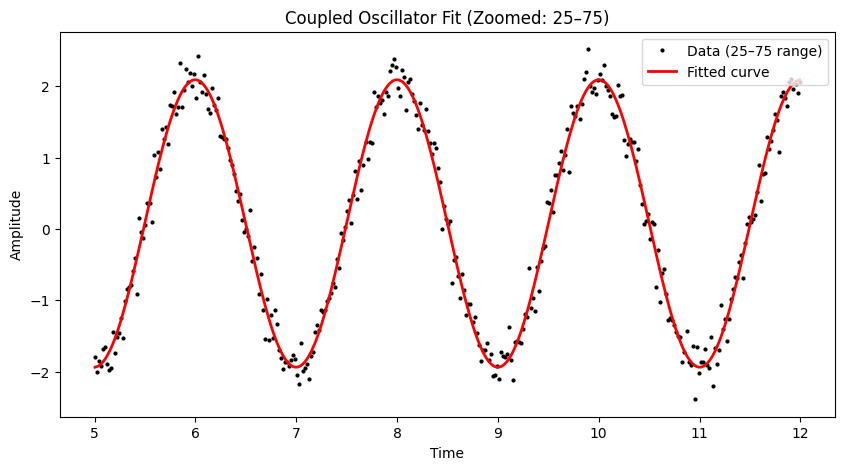

In [45]:
# Fit inphase data
popt, pcov, fit_y = fit_cosine_data(ti,yi)
print(popt)
fit_plotter(ti, yi, fit_y)

#store the frequency value in a dataframe
fit_freq = pd.DataFrame(columns=["Fit Frequency"])
fit_freq.loc["in-phase", "Fit Frequency"] = popt[1]

[-0.04075494  6.89525872  0.91619453  0.08697838]


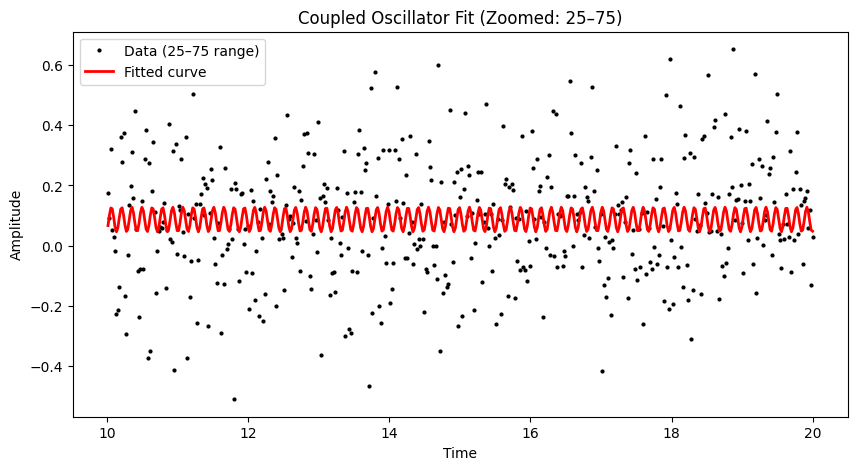

,Fit Frequency
in-phase,0.499629
out-phase,6.895259


In [46]:
# fit outphase data
popt, pcov, fit_y = fit_cosine_data(to,yo)
print(popt)
fit_plotter(to,yo,fit_y)

fit_freq.loc["out-phase", "Fit Frequency"] = popt[1]
fit_freq

In [47]:
df_combined = pd.concat([df_freq, fit_freq], axis=1)
df_combined = df_combined.apply(pd.to_numeric, errors='ignore')
df_combined = df_combined.round(2) 
df_combined

C:\Users\kctho\AppData\Local\Temp\ipykernel_16640\2000280340.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_combined = df_combined.apply(pd.to_numeric, errors='ignore')


,FFT Frequency,Fit Frequency
in-phase,0.5,0.5
out-phase,0.2,6.9


Fitted parameters:
A1=-11.7005, A2=11.9118, f1=0.5306, f2=0.5266, phi1=4.7260, phi2=4.9353, offset=0.0828


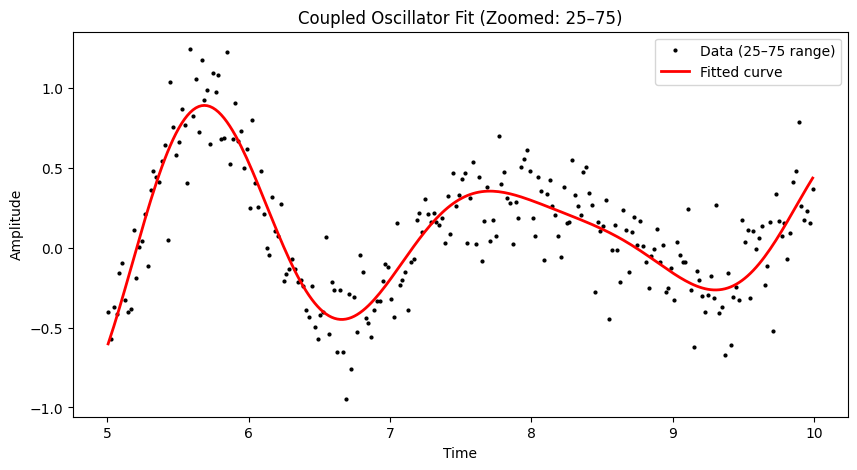

In [48]:
# Fit beats data
guess = [4, 3, 0.6, 0.49,  0.55, 2.45, np.mean(yb)] # [A1,A2,f1,f2,phi,phi2,offset]



# --- Step 4: Fit the model ---
params, cov = curve_fit(beat_func, tb, yb, p0=guess, maxfev=20000)


# Extract fitted parameters
A1, A2, f1, f2, phi1, phi2, offset = params
print(f"Fitted parameters:\nA1={A1:.4f}, A2={A2:.4f}, f1={f1:.4f}, f2={f2:.4f}, "
      f"phi1={phi1:.4f}, phi2={phi2:.4f}, offset={offset:.4f}")

# --- Step 5: Generate fitted data ---
y_fit = beat_func(tb, *params)

fit_plotter(tb,yb,y_fit)

In [49]:
df_combined["Beats"] = [f1, f2]
df_combined = df_combined.round(2) 
df_combined

,FFT Frequency,Fit Frequency,Beats
in-phase,0.5,0.5,0.53
out-phase,0.2,6.9,0.53


In [50]:
T1 = 1/f1
T2 = 1/f2
w1 = 2*np.pi*f1
w2 = 2*np.pi*f2

In [51]:
w_fast = (w1+w2)/2
w_slow = abs(w1-w2)/2
T_fast = 2*np.pi/w_fast
T_slow = 2*np.pi/w_slow

# Create a DataFrame with row names
params_df1 = pd.DataFrame({
    "Value": [f1, f2, w1, w2, T1,T2,w_fast,w_slow,T_fast,T_slow]
}, index=["f1", "f2", "w1", "w2", "T1", "T2", "w_fast", "w_slow", "T_fast","T_slow"])

# Display it
params_df1


,Value
f1,0.530643
f2,0.526645
w1,3.334129
w2,3.309007
T1,1.884506
T2,1.898813
w_fast,3.321568
w_slow,0.012561
T_fast,1.891632
T_slow,500.208523


In [52]:
# Create a DataFrame with row names
params_df = pd.DataFrame({
    "Value": [A1, A2, f1, f2, phi1, phi2, offset]
}, index=["A1", "A2", "f1", "f2", "phi1", "phi2", "offset"])

# Display it
params_df


,Value
A1,-11.700494
A2,11.911807
f1,0.530643
f2,0.526645
phi1,4.726034
phi2,4.935326
offset,0.082762
